<a href="https://colab.research.google.com/github/Eric-Schwinn-Lima/Tech-Challenge---NPS/blob/main/DataScience_Alura.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

In [5]:
notas  = pd.read_csv("ratings.csv")

In [6]:
notas.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [7]:
notas.shape

(100836, 4)

In [8]:
notas.columns = ["usuarioId", "filmeId", "nota", "momento"]
notas.head()

,usuarioId,filmeId,nota,momento
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [9]:
notas['nota'].unique()

array([4. , 5. , 3. , 2. , 1. , 4.5, 3.5, 2.5, 0.5, 1.5])

In [10]:
notas['nota'].value_counts()

,count
nota,
4.0,26818
3.0,20047
5.0,13211
3.5,13136
4.5,8551
2.0,7551
2.5,5550
1.0,2811
1.5,1791


#Analisando as notas em geral


In [11]:
print(f'Média: {notas['nota'].mean().round(2)} ')
print(f'Mediana: {notas.nota.median()}')

Média: 3.5 
Mediana: 3.5


In [12]:
notas.nota.head()

,nota
0,4.0
1,4.0
2,4.0
3,5.0
4,5.0


<Axes: ylabel='Frequency'>

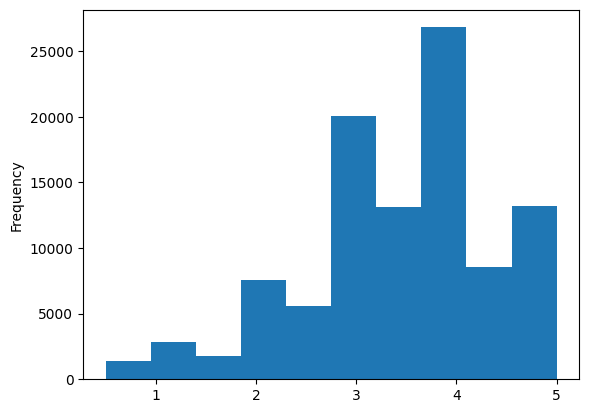

In [13]:
notas.nota.plot(kind='hist')

In [14]:
notas.nota.describe()

,nota
count,100836.000000
mean,3.501557
std,1.042529
min,0.500000
25%,3.000000
50%,3.500000
75%,4.000000
max,5.000000


In [15]:
import seaborn as sns

<Axes: ylabel='nota'>

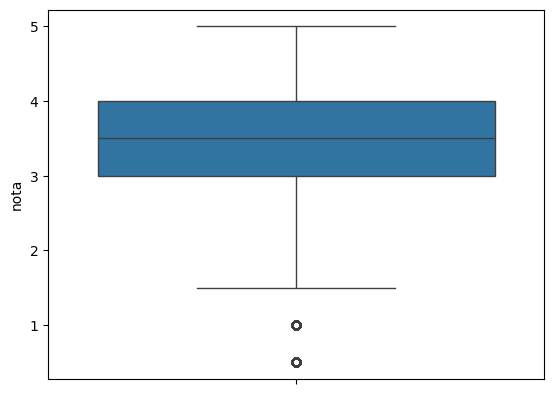

In [16]:
sns.boxplot(notas.nota)

In [17]:
filmes = pd.read_csv("movies.csv")
filmes.columns = ['filmeId', 'titulo', 'genero']
filmes.head()

,filmeId,titulo,genero
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [18]:
notas.head()

,usuarioId,filmeId,nota,momento
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


# Analisando as notas por filme


In [19]:
notas.query("filmeId==1").nota.mean().round(2)

np.float64(3.92)

In [20]:
notas.query("filmeId==2").nota.mean().round(2)

np.float64(3.43)

## Agrupar notas pelo filme


In [21]:
medias_por_filme = notas.groupby("filmeId").nota.mean().round(2)
medias_por_filme.head(10)

,nota
filmeId,
1,3.92
2,3.43
3,3.26
4,2.36
5,3.07
6,3.95
7,3.19
8,2.88
9,3.12


<Axes: ylabel='Frequency'>

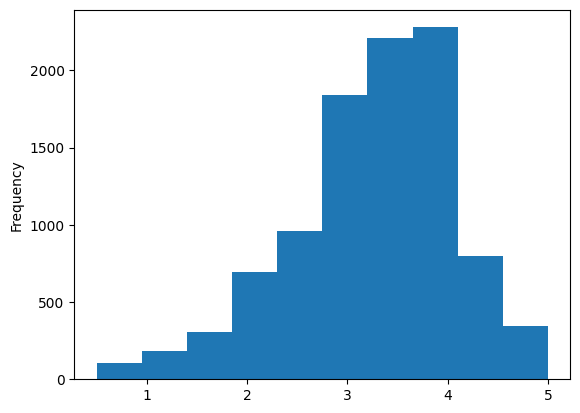

In [22]:
medias_por_filme.plot(kind='hist')

<Axes: ylabel='nota'>

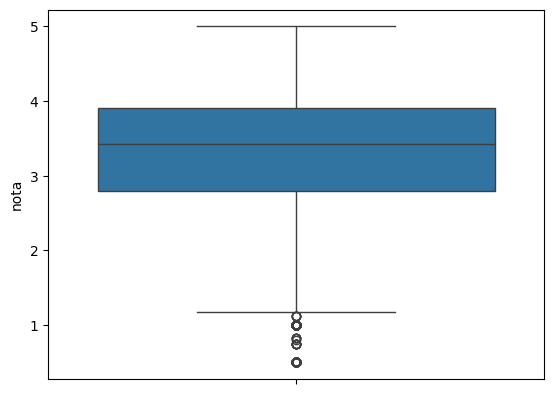

In [23]:
import matplotlib.pyplot as plt


sns.boxplot(medias_por_filme)

/tmp/ipykernel_616/1462563176.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(medias_por_filme, bins=40)


<Axes: xlabel='nota', ylabel='Density'>

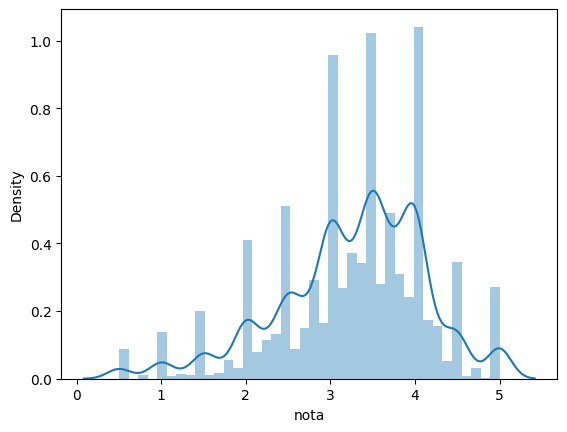

In [24]:
sns.distplot(medias_por_filme, bins=40)

Text(0, 0.5, 'Frequência')

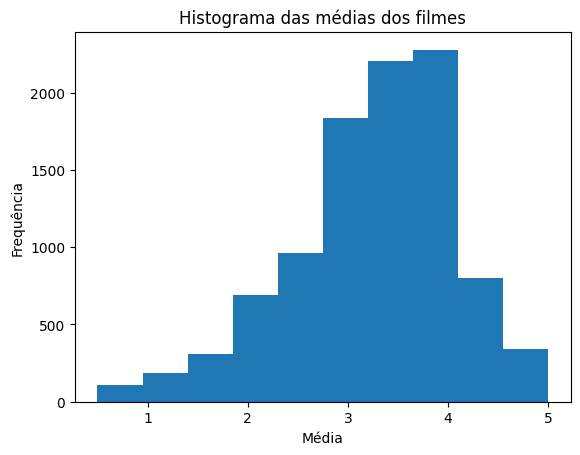

In [25]:
import matplotlib.pyplot as plt
plt.hist(medias_por_filme)
plt.title("Histograma das médias dos filmes")
plt.xlabel("Média")
plt.ylabel("Frequência")
#

In [26]:
tmdb = pd.read_csv("tmdb_5000_movies.csv")
tmdb.head()


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [27]:
tmdb.original_language.unique()

array(['en', 'ja', 'fr', 'zh', 'es', 'de', 'hi', 'ru', 'ko', 'te', 'cn',
       'it', 'nl', 'ta', 'sv', 'th', 'da', 'xx', 'hu', 'cs', 'pt', 'is',
       'tr', 'nb', 'af', 'pl', 'he', 'ar', 'vi', 'ky', 'id', 'ro', 'fa',
       'no', 'sl', 'ps', 'el'], dtype=object)

In [28]:
tmdb.original_language.value_counts()

,count
original_language,
en,4505
fr,70
es,32
zh,27
de,27
hi,19
ja,16
it,14
cn,12


In [29]:
tmdb.original_language.value_counts().index

Index(['en', 'fr', 'es', 'zh', 'de', 'hi', 'ja', 'it', 'cn', 'ko', 'ru', 'pt',
       'da', 'sv', 'nl', 'fa', 'th', 'he', 'id', 'cs', 'ta', 'ro', 'ar', 'te',
       'hu', 'xx', 'af', 'is', 'tr', 'vi', 'pl', 'nb', 'ky', 'no', 'sl', 'ps',
       'el'],
      dtype='object', name='original_language')

In [30]:
tmdb.original_language.value_counts().values

array([4505,   70,   32,   27,   27,   19,   16,   14,   12,   11,   11,
          9,    7,    5,    4,    4,    3,    3,    2,    2,    2,    2,
          2,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
          1,    1,    1,    1])

In [38]:
contagem_lingua = tmdb.original_language.value_counts().to_frame().reset_index()
contagem_lingua.columns = ['original_language', 'total']
contagem_lingua

,original_language,total
0,en,4505
1,fr,70
2,es,32
3,zh,27
4,de,27
5,hi,19
6,ja,16
7,it,14
8,cn,12
9,ko,11


<Axes: xlabel='original_language', ylabel='total'>

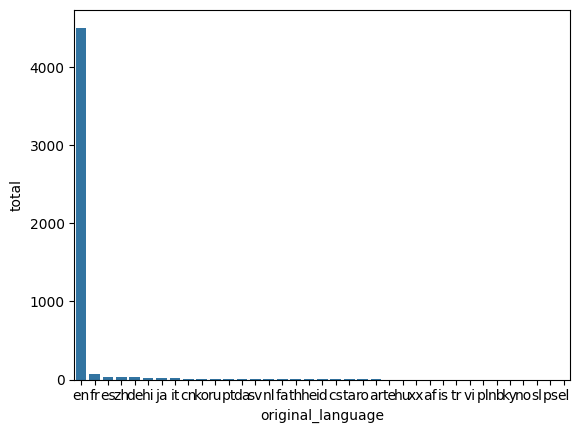

In [39]:
sns.barplot(x="original_language", y="total", data = contagem_lingua)

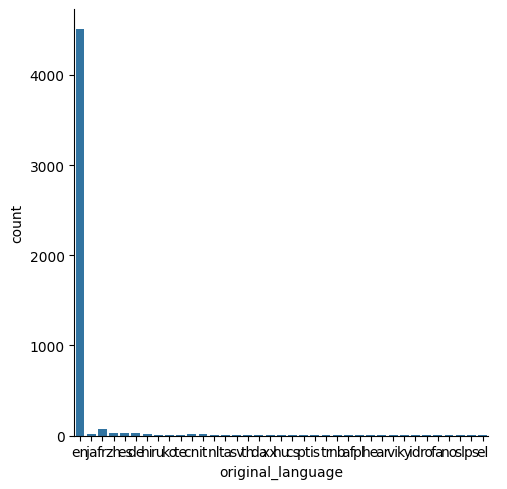

In [44]:
sns.catplot(x="original_language", data = tmdb, kind="count")


([<matplotlib.patches.Wedge at 0x7a4b11fcc440>,
 [Text(-1.0791697944848757, 0.21305528548118974, 'en'),
  Text(1.0355355060813987, -0.371033981792425, 'fr'),
  Text(1.0579676532751783, -0.30117178590202043, 'es'),
  Text(1.0687996896821872, -0.2601292435218708, 'zh'),
  Text(1.0773192231958597, -0.22222351660584796, 'de'),
  Text(1.0835168605253713, -0.18971350230609152, 'hi'),
  Text(1.0875755883723952, -0.16486157701671572, 'ja'),
  Text(1.0906010458121063, -0.14348992603503677, 'it'),
  Text(1.092883468191142, -0.12492287602557497, 'cn'),
  Text(1.094639090663068, -0.10846778873163951, 'ko'),
  Text(1.0960865548595407, -0.0927052547385707, 'ru'),
  Text(1.097205502470541, -0.078358696699014, 'pt'),
  Text(1.0979654406138135, -0.06687220063460171, 'da'),
  Text(1.0984565068410161, -0.05825206072434674, 'sv'),
  Text(1.0987803772611597, -0.05178496447641595, 'nl'),
  Text(1.0990363134163792, -0.04603457170578121, 'fa'),
  Text(1.0992355467780295, -0.041002593815593756, 'th'),
  Text(1

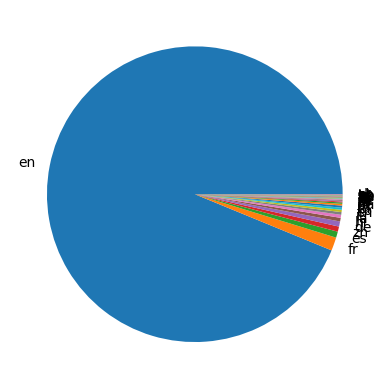

In [45]:
plt.pie(contagem_lingua.total, labels=contagem_lingua.original_language)
#

In [52]:
total_por_lingua = tmdb.original_language.value_counts()
total_geral = total_por_lingua.sum()
total_ingles = total_por_lingua.loc["en"]
total_resto = total_geral - total_ingles
print(f'Total Inglês: {total_ingles}')
print(f'Total Resto: {total_resto}')


Total Inglês: 4505
Total Resto: 298


In [53]:
dados = {
    'lingua': ['Inglês', 'outros'],
    'total': [total_ingles, total_resto]
}
dados = pd.DataFrame(dados)
dados


,lingua,total
0,Inglês,4505
1,outros,298


/tmp/ipykernel_616/557680765.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="lingua", y="total", data=dados,


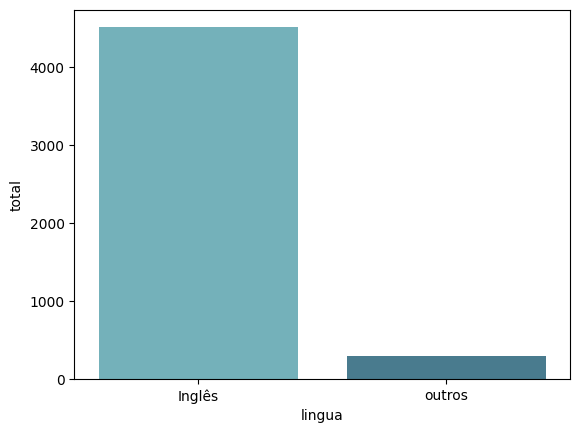

In [86]:
sns.barplot(x="lingua", y="total", data=dados,
            palette = "GnBu_d")


([<matplotlib.patches.Wedge at 0x7a4b071f2660>,
 [Text(-1.0791697944848757, 0.21305528548118974, 'Inglês'),
  Text(1.0791697115180023, -0.21305570572540808, 'outros')])

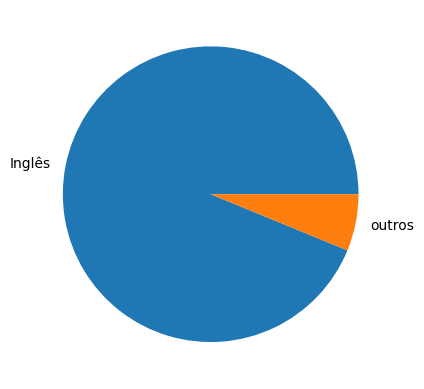

In [56]:
plt.pie(dados.total, labels = dados.lingua)

In [79]:
total_por_lingua_de_outros_filmes = tmdb.query("original_language != 'en'").original_language.value_counts()
total_por_lingua_de_outros_filmes

,count
original_language,
fr,70
es,32
zh,27
de,27
hi,19
ja,16
it,14
cn,12
ko,11


/tmp/ipykernel_616/2142653732.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x="original_language", kind="count", data=total_sem_ser_ingles,


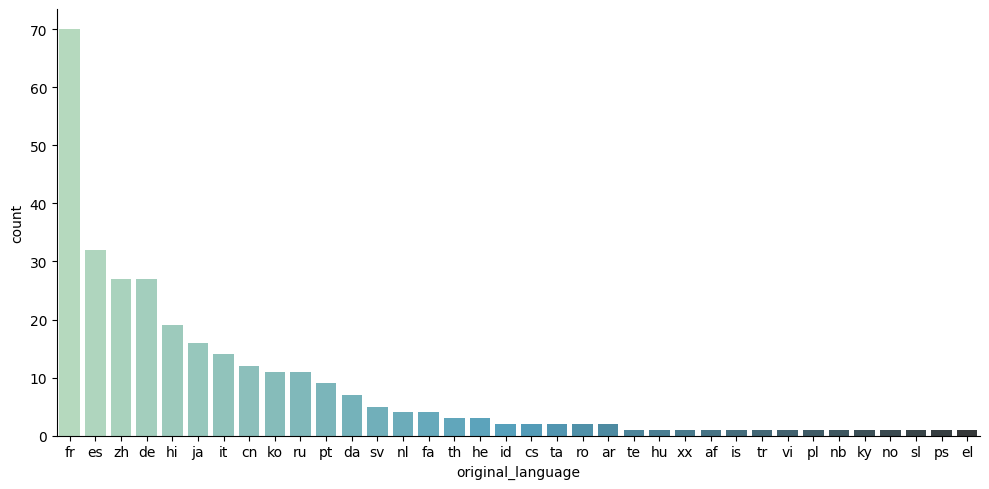

In [82]:
total_sem_ser_ingles = tmdb.query("original_language != 'en'")

#aspect altera a forma da figura
#
sns.catplot(x="original_language", kind="count", data=total_sem_ser_ingles,
            aspect = 2,
            palette = "GnBu_d",
            order = total_por_lingua_de_outros_filmes.index)

## Revisando o papel da média, mediana, medidas de tendência central, dispersão, devio padrão

In [87]:
filmes.head(2)

,filmeId,titulo,genero
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy


In [93]:
notas.head()
notas_toy_story = notas.query("filmeId==1")
notas_jumanji = notas.query("filmeId==2")
print(f'Toy Story: {len(notas_toy_story)}')
print(f'Jumanji: {len(notas_jumanji)}')


Toy Story: 215
Jumanji: 110


In [97]:
print(f'Nota média Toy Story: {notas_toy_story.mean().nota.round(2)}')
print(f'Nota média Jumanj: {notas_jumanji.mean().nota.round(2)}')

Nota média Toy Story: 3.92
Nota média Jumanj: 3.43


In [98]:
print(f'Nota média Toy Story: {notas_toy_story.median().nota.round(2)}')
print(f'Nota média Jumanj: {notas_jumanji.median().nota.round(2)}')

Nota média Toy Story: 4.0
Nota média Jumanj: 3.5


<Axes: xlabel='filmeId', ylabel='nota'>

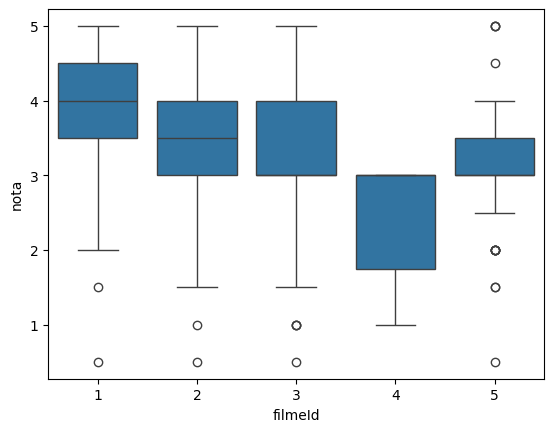

In [101]:
sns.boxplot(x = "filmeId", y = "nota", data = notas.query("filmeId in [1,2,3,4,5]"))

#Desvio Padrão

In [106]:
notas_jumanji.nota.std()
notas_toy_story.nota.std()

print(f'Desvio Padrão Toy Story: {notas_toy_story.nota.std()}')
print(f'Desvio Padrão Jumanji: {notas_jumanji.nota.std()}')

Desvio Padrão Toy Story: 0.8348591407114045
Desvio Padrão Jumanji: 0.8817134921476455
